<div style="background-color:yellow; text-align:center; vertical-align: middle; padding:40px 0;">
<a style="font-size: 30px;" >
    <font color=red> DI-504  :  Foundations of Deep Learning </font>
</a>
    <br>
    <br>
<a style="font-size: 25px;" >
    <font color=red>Final Project</font>
</a>
    <br>
    <br>
<a style="font-size: 20px;" >
    <font color=red>Turgay Yıldız , Cognitive Sciences, Middle East Technical University (METU)</font>
</a>
</div>


###### <font color=red > Note: This notebook was written in dark theme. Some text may not display correctly in light theme. </font>

### <div span style="background-color:green;"> <font color=black> $$ \text {First Import the Relevant Packages } $$ </font> </div>


In [1]:
import torch
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.checkpoint import checkpoint
from torch.cuda.amp import GradScaler, autocast
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
from torch.nn.functional import relu
from torchvision import models
import copy
import time
from collections import defaultdict
from PIL import Image
import tqdm

### <div span style="background-color:green;"> <font color=black> $$ \text {Load the Dataset} $$ </font> </div>


In [2]:
path = "/home/turgay/Turgay/Academic/2024_SPRING_/Project_omniglot/array_csv_matrix_data/npy_images/"

In [7]:
X_    =  path + "imgs_90300.npy" 

In [8]:
X     =  np.load(X_, mmap_mode="r")

### <div span style="background-color:green;"> <font color=black> $$ \text {Some Custom Functions to Create Indices :} $$ </font> </div>


In [9]:
def random_selection(data, num_elements):
    
    indices = np.random.choice(len(data), num_elements, replace=False)
    
    return data[indices] 

In [10]:
import random

def create_indices(len_dataset, num_compare): 

    i_x = []
    i_y = []

    dataset = np.arange(0, len_dataset) 

    for i in range(0, len_dataset, 20): 
    
        if (num_compare==1):

            for k in range(i, i + 20):
            
                two            = np.concatenate( (np.array([k]), random_selection(dataset[i:i+20], 1))  )
                remaining_data = np.delete(dataset, np.arange(i, i+20)) 
                other          = random_selection(remaining_data, 1) 
   
                others         = np.concatenate((np.array([k]), other), axis=0) 
    
                i_x.append(two)
                i_x.append(others)
        
                vec1         = np.ones((1)) 
       
                i_y.append(vec1) 

                vec2         = np.zeros((1)) 
       
                i_y.append(vec2) 
        
        else:
            
            for k in range(i, i + 20):
            
                two            = np.concatenate( (np.array([k]), random_selection(dataset[i:i+20], 1))  )
                remaining_data = np.delete(dataset, np.arange(i, i+20)) 
                twenty         = random_selection(remaining_data, num_compare - 1) 
                
                index_    = random.randint(0, num_compare-1) 
                insert_20 = np.insert(twenty, index_, np.array([two[1]]), axis=0)
                concat_21 = np.concatenate((np.array([two[0]]), insert_20), axis=0)
    
                i_x.append(concat_21)
        
                vec         = np.zeros((num_compare)) 
                vec[index_] = 1
                
                i_y.append(vec) 
        
    return i_x, i_y

        


In [11]:
def indices(num_loop, len_dataset, num_compare):

    img_indices_x = []
    img_indices_y = []

    for i in range(num_loop): 
        
        indices_x1, indices_y1    =  create_indices(len_dataset, num_compare)  
    
        img_indices_x.extend(indices_x1)
        img_indices_y.extend(indices_y1)
    
    return img_indices_x,  img_indices_y 

In [12]:
img_indices_x,  img_indices_y   =  indices(1, 90300, 20)  

In [14]:
len(img_indices_x)

90300

### <div span style="background-color:green;"> <font color=black> $$ \text {Two-Way Classification:} $$ </font> </div>


In [15]:
img_indices_x_2_way,  img_indices_y_2_way   =  indices(1, 90300, 1)   

In [16]:
img_indices_x_2_way[0], img_indices_y_2_way[0]        # for same images, ground truth is 1

(array([ 0, 13]), array([1.]))

In [17]:
img_indices_x_2_way[1], img_indices_y_2_way[1]        # for different images, ground truth is 0 

(array([   0, 4331]), array([0.]))

### <div span style="background-color:green;"> <font color=black> $$ \text {Twenty-Way Classification :} $$ </font> </div>


In [19]:
num = 0      

In [20]:
img_indices_x[num] , img_indices_y[num] 

(array([    0,    15,   902, 47315, 49991, 29273, 14943, 34106, 23716,
        75868, 54217, 54606, 43530, 52776, 58508, 70217, 22537, 87175,
        23254, 59514, 10001]),
 array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]))

### <div span style="background-color:green;"> <font color=black> $$ \text {This Custom Function is to Plot Images to check whether images correspond to their indices :} $$ </font> </div>


In [21]:
def plot_img(data, row, col,  size1,  size2): 

    if (row == 1) and (col == 1) : 

        fig, ax  =  plt.subplots(1, 1, figsize=(size1, size2))
        ax.imshow(data, cmap="binary") 
        ax.set_axis_off() 

    elif  (row == 1) and (col > 1):

        fig, axes  =  plt.subplots(1, col, figsize=(size1, size2))

        for i in range(col):
        
            axes[i].imshow(data[i], cmap="binary") 
            axes[i].set_axis_off() 
            axes[i].set_title(f"Image {i}")

    else :

        fig, axes  =  plt.subplots(row, col, figsize=(size1, size2))

        for i in range(row):

            for j in range(col):
        
                axes[i, j].imshow(data[i*10 + j], cmap="binary") 
                axes[i, j].set_axis_off()  
                axes[i, j].set_title(f"Image {i * 10 + j}")

    plt.tight_layout()  
    plt.show()
        

### <div span style="background-color:green;"> <font color=black> $$ \text {Let's check whether the indices are correct :} $$ </font> </div>


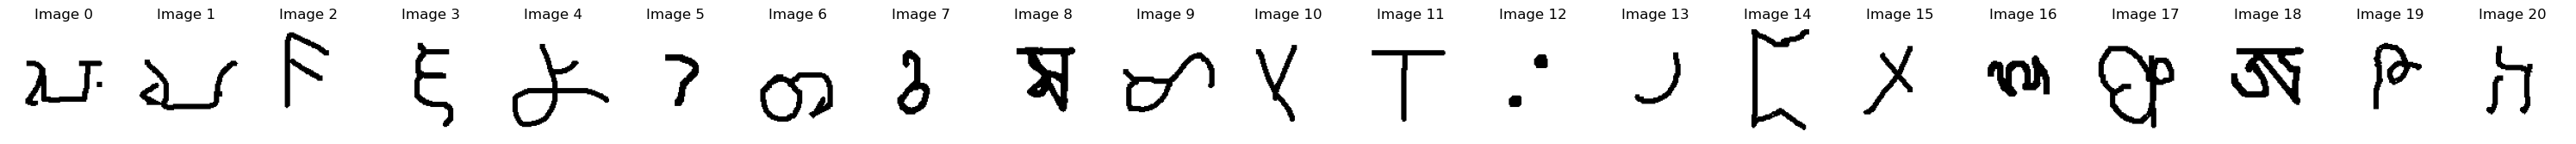

In [24]:
plot_img(X[img_indices_x[num]], 1, 21, 30, 30 ) 

In [26]:
np.argmax(img_indices_y[num]) + 1

1

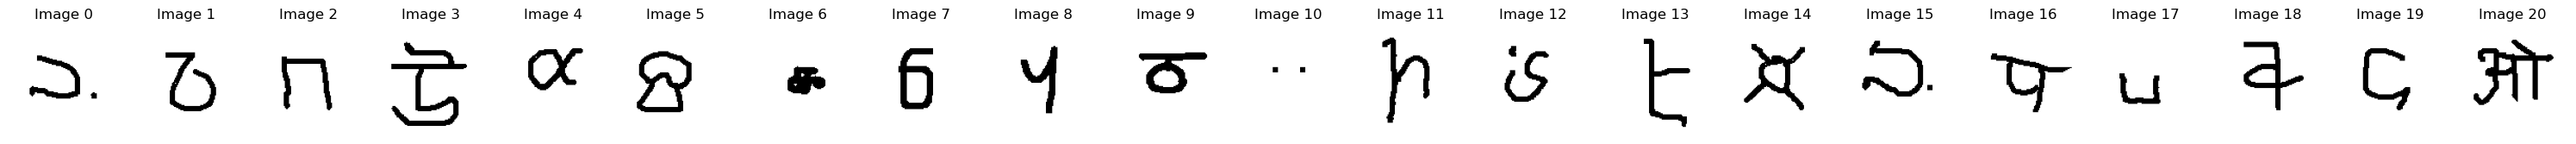

In [30]:
plot_img(X[img_indices_x[119]], 1, 21, 30, 30 ) 

In [31]:
np.argmax(img_indices_y[119]) + 1

15

### <div span style="background-color:green;"> <font color=black> $$ \text {Two diffent classes for training and testing :} $$ </font> </div>


In [2]:
import numpy as np

In [30]:
random_number = np.random.rand()

In [31]:
random_number

0.34124786750702507

In [32]:
class MyDataset_train(Dataset):
    
    def __init__(self, X_array, y_indices, transform=True):
        
        self.X = X_array
        self.y_indices = y_indices
        self.transform = transform

    def __len__(self):
        return len(self.X)   

    def __getitem__(self, idx):
        
        sample = torch.tensor(self.X[ idx ]).float() 
        label  = torch.tensor(self.y_indices[idx]).float()   

        if self.transform:
            sample = self.transform(sample)

        return sample, label


In [33]:
class MyDataset_test(Dataset):
    
    def __init__(self, X_array, x_indices, y_indices, transform=True):
        
        self.X = X_array
        self.x_indices = x_indices
        self.y_indices = y_indices
        self.transform = transform

    def __len__(self):
        return len(self.x_indices)   

    def __getitem__(self, idx):
        
        sample = torch.tensor(self.X[ self.x_indices[idx] ]).float() 
        label  = torch.tensor(self.y_indices[idx]).float()   

        if self.transform:
            sample = self.transform(sample)

        return sample, label


### <div span style="background-color:green;"> <font color=black> $$ \text {Data Augmentation:} $$ </font> </div>


In [34]:
transform = transforms.Compose([
    #ToTensorFloat(),                         # Convert image to tensor
    #transforms.ToTensor(),
    transforms.RandomResizedCrop(105),        # Randomly crop the image and resize it to 224x224
    transforms.RandomHorizontalFlip(),        # Randomly flip the image horizontally
    transforms.RandomVerticalFlip(),          # Randomly flip the image vertically
    transforms.RandomRotation(degrees=15),    # Randomly rotate the image by up to 15 degrees
    transforms.Normalize(mean=0.02274, std=0.2751)   # I calculated these values before .
   
]) 

In [11]:
dataset = MyDataset_train(X, y,  transform=transform) 

In [13]:
train_size =  int(0.8 * len(dataset))
val_size   =  len(dataset) - train_size

In [14]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size]) 

In [16]:
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=100, shuffle=True)

### <div span style="background-color:green;"> <font color=black> $$ \text {The Model :} $$ </font> </div>


In [35]:
class N_way_one_shot(nn.Module):
    
    def __init__(self, dropout_prob = 0.1):  
        
        super(N_way_one_shot, self).__init__()
        
        self.e11   = nn.Conv2d(2, 64, kernel_size=7, padding=3)                                          # 105 x 105 
        self.bn11  = nn.BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)  # 105 x 105 
        self.activation11 = nn.ReLU() 
        
        self.pool1    = nn.MaxPool2d(kernel_size=2, stride=2)        
        self.dropout1 = nn.Dropout2d(p=dropout_prob)
        
        self.e12   = nn.Conv2d(64, 128, kernel_size=5, padding=2)    
        self.bn12  = nn.BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation12 = nn.ReLU()  

        self.pool2    = nn.MaxPool2d(kernel_size=2, stride=2)      
        self.dropout2 = nn.Dropout2d(p=dropout_prob)
 
        self.e21   = nn.Conv2d(128, 256, kernel_size=5, padding=2)     
        self.bn21  = nn.BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation21 = nn.ReLU() 

        self.pool3    = nn.MaxPool2d(kernel_size=2, stride=2)      
        self.dropout3 = nn.Dropout2d(p=dropout_prob)
        
        self.e22   = nn.Conv2d(256, 512, kernel_size=5, padding=2)    
        self.bn22  = nn.BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        self.activation22 = nn.ReLU() 

        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)     #  6    x    6  pixels     
        self.dropout4 = nn.Dropout2d(p=dropout_prob)           #  6    x    6  pixels  


        # *************************** Fully Connected Layers **************************
        
        
        self.fc1    = nn.Linear(18432, 1024)        
        self.bn_fc1 = nn.BatchNorm1d(1024) 
        self.activation_fc1 = nn.ReLU()
        
        self.dropout_fc1 = nn.Dropout1d(p=dropout_prob)      
        
        self.fc2    = nn.Linear(1024, 512)       
        self.bn_fc2 = nn.BatchNorm1d(512) 
        self.activation_fc2 = nn.ReLU()
        
        self.fc3    = nn.Linear(512, 256) 
        self.bn_fc3 = nn.BatchNorm1d(256)
        self.activation_fc3 = nn.ReLU() 
        
        self.dropout_fc3 = nn.Dropout1d(p=dropout_prob)

        self.fc4    = nn.Linear(256, 128) 
        self.bn_fc4 = nn.BatchNorm1d(128)
        self.activation_fc4 = nn.ReLU()

        self.fc5    = nn.Linear(128, 64) 
        self.bn_fc5 = nn.BatchNorm1d(64) 
        self.activation_fc5 = nn.ReLU()

        self.fc6    = nn.Linear(64, 1)    

       

    def forward(self, x): 
        
    
        xe11 = self.activation11(self.bn11(self.e11(x)))     
        xp1  = self.dropout1(self.pool1(xe11)) 
        xe12 = self.activation12(self.bn12(self.e12(xp1)))
        xp2  = self.dropout2(self.pool2(xe12))
        xe21 = self.activation21(self.bn21(self.e21(xp2)))
        xp3  = self.dropout3(self.pool3(xe21))   
        xe22 = self.activation22(self.bn22(self.e22(xp3)))
        xp4  = self.dropout4(self.pool4(xe22)) 

        xfc0 = xp4.view(xp4.size(0), -1) 
     
        xfc1  = self.dropout_fc1(self.activation_fc1(self.bn_fc1(self.fc1(xfc0))))
        xfc2  = self.activation_fc2(self.bn_fc2(self.fc2(xfc1))) 
        xfc3  = self.dropout_fc3(self.activation_fc3(self.bn_fc3(self.fc3(xfc2))))
        xfc4  = self.activation_fc4(self.bn_fc4(self.fc4(xfc3)))
        xfc5  = self.activation_fc5(self.bn_fc5(self.fc5(xfc4))) 
        
        out           =   self.fc6(xfc5)         
         
        return out

   
    def initialize_weights(self):                   
        
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)  
 

Note : I trained Res-net 18 and Res-Net 50 in another ipynb files. However, since most of the codes are the same, I am going to take only the different and important parts here. I am going to upload all the weights of three models. 

### <div span style="background-color:green;"> <font color=black> $$ \text {Res-NET 18:} $$ </font> </div>


In [ ]:
class resnet_18(nn.Module):
    def __init__(self):
        
        super().__init__()
        
        self.backbone = models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

        self.backbone.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        num_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Linear(num_features, 1) 


    def forward(self, x):

        x = self.backbone(x)

        return x 



### <div span style="background-color:green;"> <font color=black> $$ \text {Res-NET 50:} $$ </font> </div>


In [ ]:
class resnet_50(nn.Module):
    def __init__(self):
        
        super().__init__()
        
        self.backbone = models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT) 

        self.backbone.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        num_features = self.backbone.fc.in_features
        
        self.backbone.fc = nn.Linear(num_features, 1)


    def forward(self, x):

        x = self.backbone(x)  

        return x 



### <div span style="background-color:green;"> <font color=black> $$ \text {To Employ GPU :} $$ </font> </div>


In [36]:
device    = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [37]:
model  =  N_way_one_shot().to(device) 

### <div span style="background-color:green;"> <font color=black> $$ \text {Number of Parameters :} $$ </font> </div>


In [38]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of trainable parameters in the model:", num_params)

Number of trainable parameters in the model: 23886657


### <div span style="background-color:green;"> <font color=black> $$ \text {Loss Function :} $$ </font> </div>


In [22]:
criterion = nn.BCEWithLogitsLoss() 

### <div span style="background-color:green;"> <font color=black> $$ \text { Initial Learning Rate :} $$ </font> </div>


In [23]:
lr=0.01

### <div span style="background-color:green;"> <font color=black> $$ \text {Optimizer :} $$ </font> </div>


In [24]:
optimizer = optim.Adam(model.parameters(), lr=lr)  

### <div span style="background-color:green;"> <font color=black> $$ \text {Scheduler:} $$ </font> </div>


In [25]:
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.8)      

### <div span style="background-color:green;"> <font color=black> $$ \text {To find best Learning Rate Scheduler settings:} $$ </font> </div>


In [39]:
def lr_scheduler_plot(initial_lr, steps, gamma, batch_size):

    data   = [initial_lr] * int(batch_size / steps)  

    lr_r_s = sorted([data[i] * gamma**i for i in range(int(batch_size / steps))]  * steps, reverse=True)
    
    plt.plot(np.arange(batch_size),  lr_r_s, "r-", label="Step Learning Rate Scheduler") 
    
    plt.xlabel("Epochs")
    plt.ylabel("Learning rate") 
    plt.legend()

    return lr_r_s

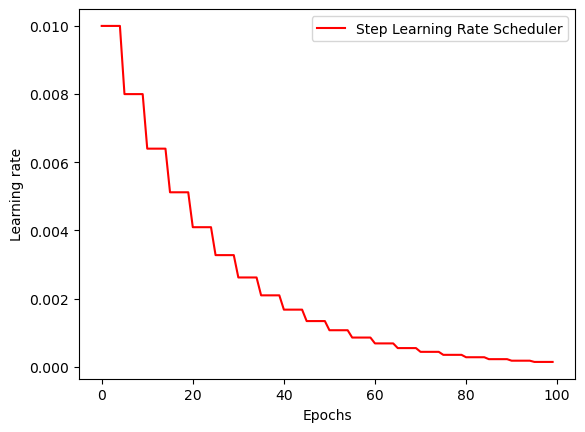

In [43]:
ls = lr_scheduler_plot(0.01, 5, 0.8, 100)

In [45]:
ls[-1]

0.00014411518807585602

### <div span style="background-color:green;"> <font color=black> $$ \text {Gradient Scaler for Computational Efficiency :} $$ </font> </div>


In [26]:
scaler = GradScaler()

### <div span style="background-color:green;"> <font color=black> $$ \text {To save the information :} $$ </font> </div>


In [27]:
path_model   =  "/home/turgay/Turgay/Academic/2024_SPRING_/Project_omniglot/array_csv_matrix_data/Two_way_one_shot_weights_3.pth"
path_losses  =  "/home/turgay/Turgay/Academic/2024_SPRING_/Project_omniglot/array_csv_matrix_data/Two_way_one_shot_losses_3.pth"

In [28]:
#torch.save({
            'model_state_dict': model.state_dict(),
            'best_loss': 999999999999999999999,
        }, path_model)   

In [ ]:
#torch.save({
            'train_loss': [],
            'val_loss'  : [],
            'epochs'    : [],
        }, path_losses)    

In [29]:
checkpoint_weights = torch.load(path_model) 
checkpoint_losses  = torch.load(path_losses)  

model.load_state_dict(checkpoint_weights['model_state_dict'])

best_loss   =  checkpoint_weights['best_loss'] 
train_loss  =  checkpoint_losses['train_loss']
val_loss    =  checkpoint_losses['val_loss'] 
epochs      =  checkpoint_losses['epochs'] 

In [30]:
best_loss

99999999

### <div span style="background-color:green;"> <font color=black> $$ \text {Initialize Weights :} $$ </font> </div>


In [ ]:
model.initialize_weights()

### <div span style="background-color:green;"> <font color=black> $$ \text {Some Hyper-parameters :} $$ </font> </div>


In [33]:
# Define early stopping parameters

patience      = 10  
counter       = 0
num_epochs    = ____ 

### <div span style="background-color:green;"> <font color=black> $$ \text {Hyper-parameter Tuning :} $$ </font> </div>


In [37]:
data = []

In [38]:
import itertools
import torch.nn as nn
import torch.optim as optim


learning_rates          =   [0.001, 0.0001, 0.00001] 
batch_sizes             =   [32, 64, 100]  
criterions              =   [nn.BCEWithLogitsLoss() , nn.MSELoss()]
optimizers              =   [optim.Adam, optim.RMSprop] 

In [ ]:
for  lr, batch_size, criterion, optimizer_cls in itertools.product( learning_rates, batch_sizes, criterions, optimizers):

    device    =  torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model     =  N_way_one_shot().to(device) 
    optimizer =  optimizer_cls(model.parameters(), lr=lr)   

    train_dataloader   =   train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_dataloader   =   val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

    model.initialize_weights() 

    torch.save({
            'train_loss': [],
            'val_loss'  : [],
            'epochs'    : [],
            'best_loss': 99999999,
        }, path_losses)    

    print("##########################################################################################################################")
    
    print(f"Hyperparameters: , lr={lr}, batch_size={batch_size}, criterion={criterion.__class__.__name__}, optimizer={optimizer.__class__.__name__}")
    
    #********************************************************************************************
    patience      = 10  
    counter       = 0
    
    for epoch in range(10):  
    
        total_loss_train = 0.0
        
        model.train()  
        
        for inputs, targets in tqdm.tqdm(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()  
            
            pred    = model(inputs)
            pred    = pred.to(device)
            loss    = criterion(pred, targets) 
            
            total_loss_train += loss.item()
    
            loss.backward()
            optimizer.step()                  
        
        total_loss_train /= len(train_loader)
        train_loss.append(total_loss_train)
    
        total_loss_train_tensor = torch.tensor(total_loss_train)
    
        if torch.isnan(total_loss_train_tensor):
            print("nan value is encountered !")
    
            break
    
        print("---------------------------------------------------------------------------")
        print(f"Epoch {epoch+1}, total_loss_TRAIN: {total_loss_train}")
        print("---------------------------------------------------------------------------")
        
     #*********************************************************************************************************************   
        
        model.eval()  
        total_loss_val = 0.0
        
        with torch.no_grad():
            for inputs, targets in tqdm.tqdm(val_loader): 
                inputs, targets = inputs.to(device), targets.to(device)
                
                pred    = model(inputs)
                pred    = pred.to(device)
                loss    = criterion(pred, targets) 
                
                total_loss_val += loss.item()
            
            total_loss_val /= len(val_loader)
            val_loss.append(total_loss_val)
            
            print(f"Epoch {epoch+1}, total_loss_VALIDATION: {total_loss_val}") 
            
            if (len(val_loss) >= 2):
              
                print("Change in loss : ", val_loss[-2] - val_loss[-1] ) 
                
            if total_loss_val < best_loss:
                print("*************...saving best model *************")
                best_loss = total_loss_val 
    
            
            torch.save({
                        'train_loss': train_loss,
                        'val_loss'  : val_loss,
                        'epochs'    : epochs ,
                        'best_loss' : best_loss
                        }, path_losses) 
    
        
        if (len(val_loss) >= 2) and (val_loss[-2] > val_loss[-1]):
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping!")
                break
                
     
        torch.cuda.empty_cache() 

    preds_t, targets_t  =  get_preds_and_targets(train_dataset, model, "two_way")
    accuracy_rate_t     =  test(preds_t, targets_t, "two_way")  

    preds_v, targets_v  =  get_preds_and_targets(val_dataset, model, "two_way")
    accuracy_rate_v     =  test(preds_v, targets_v, "two_way") 
    


    dict1 = { "lr" : lr, "accuracy_rate_t" : accuracy_rate_t, "accuracy_rate_v" : accuracy_rate_v,   "batch_size" : batch_size, "criterion" : criterion, "optimizer_cls" : optimizer_cls , "train_loss_list" : train_loss, "val_loss_list" : val_loss, "best_loss" : best_loss }

    data.append(dict1) 
    
    print("##########################################################################################################################")



In [41]:
#np.save("data.npy", data)

### <div span style="background-color:green;"> <font color=black> $$ \text {Check the Hyper-parameters Tuning Results :} $$ </font> </div>


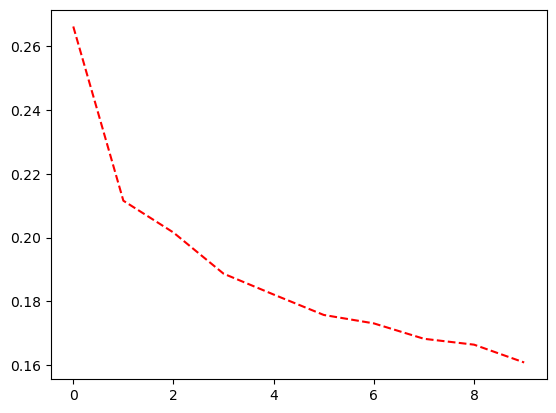

In [87]:
plt.plot(data1[2]["train_loss_list"], "r--")

### <div span style="background-color:green;"> <font color=black> $$ \text {To plot results, We'll Create a DataFrame :} $$ </font> </div>


In [80]:
data1 = []

In [81]:
tr_losses  =  data[-1]["train_loss_list"]
val_losses =  data[-1]["val_loss_list"]

In [82]:
for i in data:

    for j in range(0, 360, 10): 

        dict1 = { "lr" : i["lr"], "batch_size" : i["batch_size"], "criterion" : i["criterion"], "optimizer_cls" : i["optimizer_cls"] , "train_loss_list" : tr_losses[j : j +10], "val_loss_list" : val_losses[j : j +10], "accuracy_rate_t" : i["accuracy_rate_t"], "accuracy_rate_v" : i["accuracy_rate_v"] }

        data1.append(dict1)

In [88]:
for d in data1:
    
    d['criterion']      =  str(d['criterion'])
    d['optimizer_cls']  =  d['optimizer_cls'].__name__
 

In [91]:
import pandas as pd

In [94]:
df_list = []
for d in data1:
    for i, (train_loss, val_loss) in enumerate(zip(d['train_loss_list'], d['val_loss_list'])):
        df_list.append({
           
            'lr': d['lr'],
            'batch_size': d['batch_size'],
            'criterion': d['criterion'],
            'optimizer_cls': d['optimizer_cls'],
            'epoch': i,
            'train_loss': train_loss,
            'val_loss': val_loss,   
            'train_acc': d["accuracy_rate_t"],
            'val_acc': d["accuracy_rate_v"] 
        })

df = pd.DataFrame(df_list)

In [103]:
df.head(10)

,lr,batch_size,criterion,optimizer_cls,epoch,train_loss,val_loss,train_acc,val_acc
0,0.001,32,BCEWithLogitsLoss(),Adam,0,0.619213,0.534079,1.0,1.0
1,0.001,32,BCEWithLogitsLoss(),Adam,1,0.547397,0.493882,1.0,1.0
2,0.001,32,BCEWithLogitsLoss(),Adam,2,0.528293,0.477817,1.0,1.0
3,0.001,32,BCEWithLogitsLoss(),Adam,3,0.510762,0.444763,1.0,1.0
4,0.001,32,BCEWithLogitsLoss(),Adam,4,0.498207,0.437407,1.0,1.0
5,0.001,32,BCEWithLogitsLoss(),Adam,5,0.484297,0.413592,1.0,1.0
6,0.001,32,BCEWithLogitsLoss(),Adam,6,0.479315,0.417499,1.0,1.0
7,0.001,32,BCEWithLogitsLoss(),Adam,7,0.468370,0.406982,1.0,1.0
8,0.001,32,BCEWithLogitsLoss(),Adam,8,0.456598,0.387141,1.0,1.0
9,0.001,32,BCEWithLogitsLoss(),Adam,9,0.446172,0.369421,1.0,1.0


In [97]:

df['lr']            =   df['lr'].astype(float)
df['batch_size']    =   df['batch_size'].astype(int)
df['criterion']     =   df['criterion'].astype(str)
df['optimizer_cls'] =   df['optimizer_cls'].astype(str)
df['epoch']         =   df['epoch'].astype(int)

In [98]:
np.save("df.npy", df) 

### <div span style="background-color:green;"> <font color=black> $$ \text {Plots for Hyper-parameter Tuning Results :} $$ </font> </div>


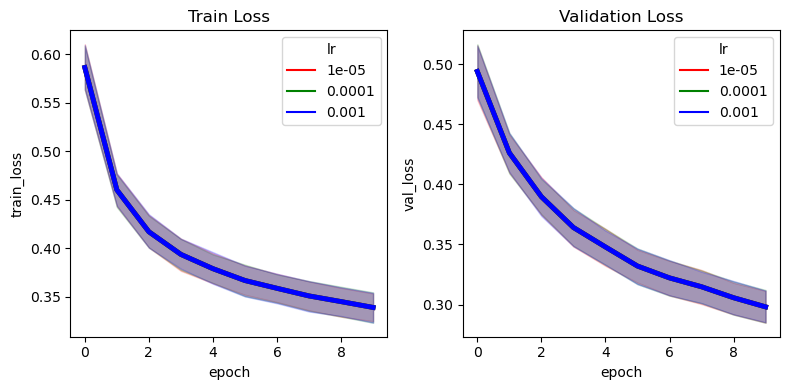

In [118]:
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, message="use_inf_as_na option is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning, message="When grouping with a length-1 list-like*")

titles = ["Train Loss", "Validation Loss"]

fig, axes   =   plt.subplots(1,2, figsize=(8, 4))



sns.lineplot(data=df, x='epoch', y='train_loss', hue=df["lr"],  ax= axes[0],  linewidth=3.5, palette=['r', 'g', 'b'])
   
sns.lineplot(data=df, x='epoch', y='val_loss',   hue=df["lr"],  ax= axes[1],  linewidth=3.5, palette=['r', 'g', 'b'])
    
axes[0].set_title(f'{titles[0]}')
axes[1].set_title(f'{titles[1]}')

plt.tight_layout()

plt.show()


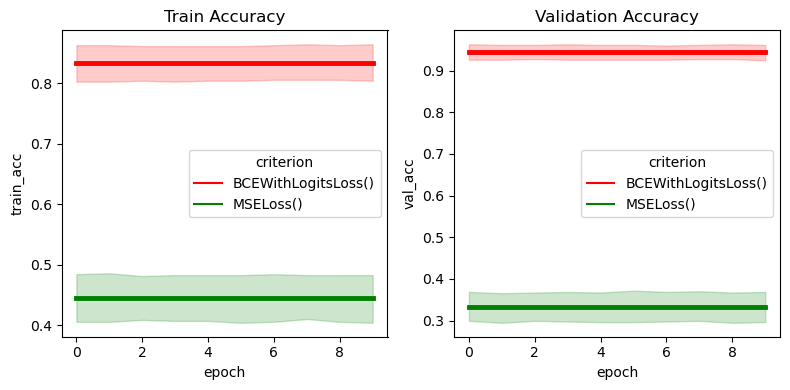

In [119]:
warnings.filterwarnings("ignore", category=FutureWarning, message="use_inf_as_na option is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning, message="When grouping with a length-1 list-like*")

titles = ["Train Accuracy", "Validation Accuracy"]

fig, axes   =   plt.subplots(1,2, figsize=(8, 4))



sns.lineplot(data=df, x='epoch', y='train_acc', hue=df["criterion"],  ax= axes[0],  linewidth=3.5, palette=['r', 'g'])
   
sns.lineplot(data=df, x='epoch', y='val_acc',   hue=df["criterion"],  ax= axes[1],  linewidth=3.5, palette=['r', 'g'])
    
axes[0].set_title(f'{titles[0]}')
axes[1].set_title(f'{titles[1]}')

plt.tight_layout()

plt.show()


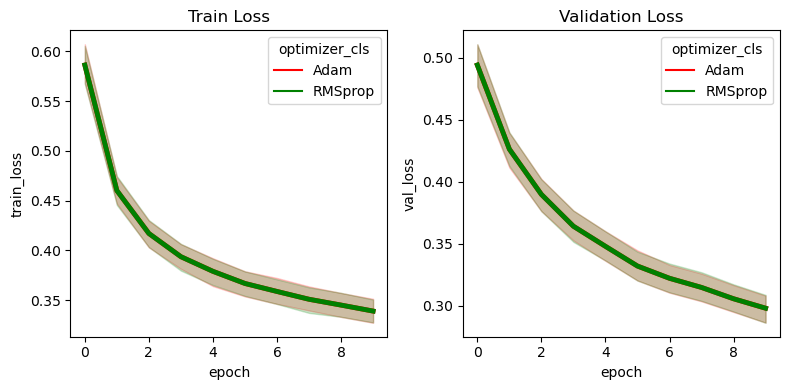

In [122]:
warnings.filterwarnings("ignore", category=FutureWarning, message="use_inf_as_na option is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning, message="When grouping with a length-1 list-like*")

titles = ["Train Loss", "Validation Loss"]

fig, axes   =   plt.subplots(1,2, figsize=(8, 4))



sns.lineplot(data=df, x='epoch', y='train_loss', hue=df["optimizer_cls"],  ax= axes[0],  linewidth=3.5, palette=['r', 'g'])
   
sns.lineplot(data=df, x='epoch', y='val_loss',   hue=df["optimizer_cls"],  ax= axes[1],  linewidth=3.5, palette=['r', 'g'])
    
axes[0].set_title(f'{titles[0]}')
axes[1].set_title(f'{titles[1]}')

plt.tight_layout()

plt.show()


### <div span style="background-color:green;"> <font color=black> $$ \text {Train and Validation :} $$ </font> </div>


In [ ]:

for epoch in range(num_epochs): 

    total_loss_train = 0.0
    
    model.train()  
    
    for inputs, targets in tqdm.tqdm(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()  
        
        pred    = model(inputs)
        pred    = pred.to(device)
        loss    = criterion(pred, targets) 
        
        total_loss_train += loss.item()

        loss.backward()
        optimizer.step() 
        
    scheduler.step()                   
    
    total_loss_train /= len(train_loader)
    train_loss.append(total_loss_train)

    total_loss_train_tensor = torch.tensor(total_loss_train)

    if torch.isnan(total_loss_train_tensor):
        print("nan value is encountered !")

        break

    print("---------------------------------------------------------------------------")
    print(f"Epoch {epoch+1}, total_loss_TRAIN: {total_loss_train}")
    print("---------------------------------------------------------------------------")
    
 #*********************************************************************************************************************   
    
    model.eval()  
    total_loss_val = 0.0
    
    with torch.no_grad():
        for inputs, targets in tqdm.tqdm(val_loader): 
            inputs, targets = inputs.to(device), targets.to(device)
            
            pred    = model(inputs)
            pred    = pred.to(device)
            loss    = criterion(pred, targets) 
            
            total_loss_val += loss.item()
        
        total_loss_val /= len(val_loader)
        val_loss.append(total_loss_val)
        
        print(f"Epoch {epoch+1}, total_loss_VALIDATION: {total_loss_val}") 
        
        if (len(val_loss) >= 2):
          
            print("Change in loss : ", val_loss[-2] - val_loss[-1] ) 
            
        if total_loss_val < best_loss:
            print("*************...saving best model *************")
            print("************* New learning rate : *************", lr) 
            best_loss = total_loss_val 

            torch.save({
                        'model_state_dict': model.state_dict(),   # state of best losses 
                        'best_loss': best_loss, 
                        }, path_model) 
    
        epochs.append(epoch)
        
        torch.save({
                    'train_loss': train_loss,
                    'val_loss'  : val_loss,
                    'epochs'    : epochs 
                    }, path_losses) 

    
    if (len(val_loss) >= 2) and (val_loss[-2] > val_loss[-1]):
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break
            
 
    torch.cuda.empty_cache() 

### <div span style="background-color:green;"> <font color=black> $$ \text {Plot for Validation and Training Losses  :} $$ </font> </div>


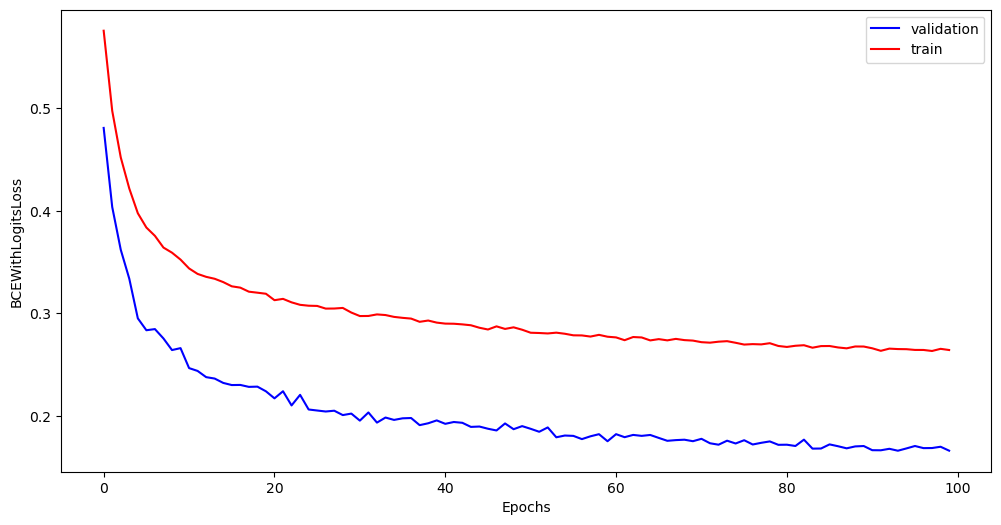

In [58]:
fig, ax = plt.subplots(1,1, figsize=(12,6))
ax.plot(val_loss, "b-", label="validation")
ax.plot(train_loss, "r-", label="train")
ax.set_xlabel("Epochs")
ax.set_ylabel("BCEWithLogitsLoss")
ax.legend()

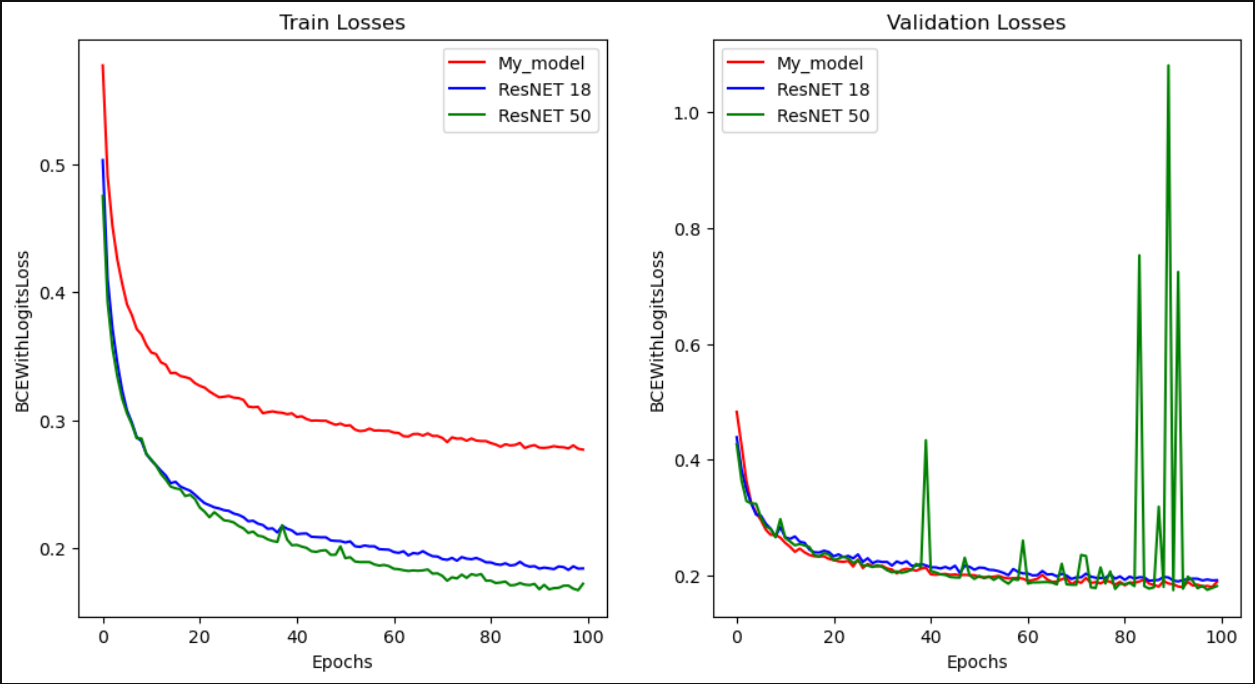

### <div span style="background-color:green;"> <font color=black> $$ \text {Some Custom Functions for Two and Twenty Way One-Shot Classifications:} $$ </font> </div>


In [35]:
def get_preds_and_targets(dataset, model, comparisions_way): 

    preds   = []
    targets = []

    if(comparisions_way=="two_way"):

        loader  = DataLoader(dataset, batch_size=64, shuffle=True) 
        
        model.eval()
        
        with torch.no_grad():
        
            for inp, tr in loader:
                
                inp  = inp.to(device)   
                pred = model(inp) 
        
                preds.append(torch.sigmoid(pred)) 
                targets.append(tr)

    if(comparisions_way=="twenty_way"):

        loader  = DataLoader(dataset, batch_size=1, shuffle=True) 
        
        model.eval() 
        
        with torch.no_grad():
        
            for inp, t in loader:
                
                inp  = inp.reshape(21, 105, 105).to(device) 
        
                comparisions = torch.zeros((20, 2, 105, 105))
        
                comparisions[:,0,:,:] = inp[0] 
                
                for i in range(20):
                
                    comparisions[i, 1, :, :] = inp[i+1, :, :]
        
                comparisions  = comparisions.to(device)
                
                pred = model(comparisions) 
        
                pred = torch.sigmoid(pred.reshape(20)) 
        
                preds.append(pred) 
                targets.append(torch.argmax(t).item()) 

    return preds, targets 

In [ ]:
preds, targets  =  get_preds_and_targets(dataset, model, comparisions_way)

In [36]:
def test(preds, targets, comparisions_way): 
    
    correct = 0
    all_    = 0
    
    if(comparisions_way=="two_way"):   
        
        for i in range(len(preds)): 
        
            for j in range(len(preds[i])):  
        
                if((preds[0][0]).item() > 0.5):
        
                    prediction = 1
        
                if((preds[0][0]).item() < 0.5):
        
                    prediction = 0
        
            
                if(prediction == targets[0][0].item()): 
            
                    correct = correct + 1
                    all_    = all_ + 1
            
                else:
            
                    all_    = all_ + 1
                    
        accuracy_rate = (correct / all_)
        error_rate    = (1 - (correct / all_))
        
        print("----------------------------------------------------------------------------------------")
        print(f"Number of correct predictions: {correct}")
        print(f"Number of wrong  predictions : {all_ - correct}")
        print(f"Number of accuracy rate      : {accuracy_rate}")
        print(f"Number of error rate         : {error_rate}") 
        print("----------------------------------------------------------------------------------------") 
         
                
            
    if(comparisions_way=="twenty_way"):

        for pred, gt in zip(preds, targets):
            
            if torch.argmax(pred).item() == gt: 
                
                correct = correct + 1
                all_    = all_ + 1
            
            else:
                all_    = all_ + 1
        
        accuracy_rate = (correct / all_)
        error_rate    = (1 - (correct / all_))
        
        print("----------------------------------------------------------------------------------------")
        print(f"Number of correct predictions: {correct}")
        print(f"Number of wrong  predictions : {all_ - correct}")
        print(f"Number of accuracy rate      : {accuracy_rate}")
        print(f"Number of error rate         : {error_rate}") 
        print("----------------------------------------------------------------------------------------") 

    return accuracy_rate

In [ ]:
accuracy_rate = test(preds, targets, comparisions_way) 

In [24]:
len(one_shot)

13180

In [29]:
img_indices_x,  img_indices_y   =  indices(1, 13180, 20)  

In [30]:
dataset = MyDataset_test(one_shot, img_indices_x, img_indices_y,  transform=transform) 

In [31]:
preds , targets = get_preds_and_targets(dataset, model,  "twenty_way")

In [80]:
test(preds, targets, "twenty_way")    # number of batches is determined in the function. 

----------------------------------------------------------------------------------------
Number of correct predictions: 11024
Number of wrong  predictions : 2156
Number of accuracy rate      : 0.8364188163884674
Number of error rate         : 0.16358118361153262
----------------------------------------------------------------------------------------


In [ ]:

twenty_way_corr  =  {   "val_correct": 832, "val_wrong": 132, "one_shot_correct": 11024, "one_shot_wrong": 2156 }


twenty_way_acc_rates  =  { "val_acc_rate": 0.86, "val_err_rate": 0.14, "one_shot_acc_rate": 0.84, "one_shot_err_rate": 0.16,}


literature = {"BPL": 3.3, "People ": 4.5 ,"Deep Siamese": 8, "Deep CNN": 13.5,"My Model: ": 16.3, "ResNET 50": 18.2, "ResNET 18" : 19.6, "HD Model": 34.8 , "Baseline ": 38.8}


### <div span style="background-color:green;"> <font color=black> $$ \text {Comparisons of All Models:} $$ </font> </div>


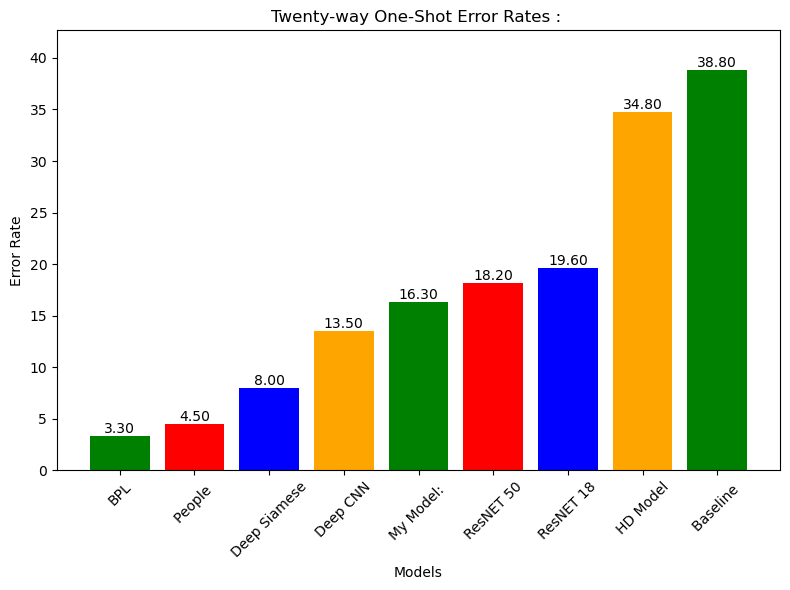

In [2]:
def plot_results(data):


    # Extract keys and values
    categories = list(data.keys())
    values     = list(data.values())
    
    # Define colors for each bar
    colors = ['green', 'red', 'blue', 'orange']
    
    # Create the bar plot
    plt.figure(figsize=(8,6))
    
    bars = plt.bar(categories, values, color=colors)
    
    # Add labels and title
    plt.xlabel('Models')
    plt.ylabel('Error Rate')
    plt.title('Twenty-way One-Shot Error Rates : ')
    plt.xticks(rotation=45)
    plt.ylim(0, max(values) * 1.1)  # Add some space above the highest bar
    #plt.ylim(0, 1)
    
    # Display values on top of the bars
    #for bar in bars:
    #    yval = bar.get_height()
    #    plt.text(bar.get_x() + bar.get_width() / 2.0, yval, int(yval), ha='center', va='bottom')
    
    for bar, value in zip(bars, values):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, yval, f"{yval:.2f}", ha='center', va='bottom')
    
    
    # Show plot
    plt.tight_layout()
    plt.show()
